In [1]:
%%capture
!pip install numpy pandas --upgrade -q --disable-pip-version-check

In [2]:
!pip install --upgrade transformers

In [3]:
%%capture
!pip install transformers accelerate datasets scikit-learn pandas matplotlib seaborn -q

In [4]:
import warnings
warnings.filterwarnings("ignore")

import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

print("All imports successful.")

All imports successful.


In [5]:
# Synthetic Support Ticket Dataset
# Replace with: df = pd.read_csv('your_tickets.csv')

tickets_data = [
    # Billing
    {"ticket_id": 1,  "text": "I was charged twice for my subscription this month. Please refund the extra amount.", "true_label": "billing"},
    {"ticket_id": 2,  "text": "My invoice shows incorrect tax calculation. Can you correct and resend it?", "true_label": "billing"},
    {"ticket_id": 3,  "text": "I cannot update my payment method. The page keeps throwing an error.", "true_label": "billing"},
    {"ticket_id": 4,  "text": "Why was my credit card declined even though it has sufficient funds?", "true_label": "billing"},
    {"ticket_id": 5,  "text": "I need a receipt for my last three payments for expense reimbursement.", "true_label": "billing"},

    # Technical Issue
    {"ticket_id": 6,  "text": "The app crashes every time I try to upload a file larger than 10 MB.", "true_label": "technical_issue"},
    {"ticket_id": 7,  "text": "Login page is not loading. I keep getting a 502 Bad Gateway error.", "true_label": "technical_issue"},
    {"ticket_id": 8,  "text": "My dashboard shows data from last week, not refreshing with current stats.", "true_label": "technical_issue"},
    {"ticket_id": 9,  "text": "API integration keeps timing out after exactly 30 seconds.", "true_label": "technical_issue"},
    {"ticket_id": 10, "text": "Push notifications are not working on my Android device since the last update.", "true_label": "technical_issue"},

    # Account Management
    {"ticket_id": 11, "text": "I forgot my password and the reset email is not arriving in my inbox.", "true_label": "account_management"},
    {"ticket_id": 12, "text": "How do I add another user to my team account with admin privileges?", "true_label": "account_management"},
    {"ticket_id": 13, "text": "I need to change the email address associated with my account.", "true_label": "account_management"},
    {"ticket_id": 14, "text": "Please delete my account and remove all my personal data per GDPR.", "true_label": "account_management"},
    {"ticket_id": 15, "text": "Two-factor authentication is not sending the OTP to my phone number.", "true_label": "account_management"},

    # Product Feedback
    {"ticket_id": 16, "text": "It would be great if you could add a dark mode to the mobile app.", "true_label": "product_feedback"},
    {"ticket_id": 17, "text": "The new UI redesign is confusing. The old layout was much more intuitive.", "true_label": "product_feedback"},
    {"ticket_id": 18, "text": "Can you add bulk export functionality to the reporting module?", "true_label": "product_feedback"},
    {"ticket_id": 19, "text": "The search feature is too slow when filtering more than 1000 records.", "true_label": "product_feedback"},
    {"ticket_id": 20, "text": "I love the new calendar integration feature! It saves me a lot of time.", "true_label": "product_feedback"},

    # Shipping & Delivery
    {"ticket_id": 21, "text": "My order was supposed to arrive 3 days ago but tracking shows no update.", "true_label": "shipping_delivery"},
    {"ticket_id": 22, "text": "I received the wrong item in my package. How do I return it?", "true_label": "shipping_delivery"},
    {"ticket_id": 23, "text": "Can I change my delivery address? The order hasn't been dispatched yet.", "true_label": "shipping_delivery"},
    {"ticket_id": 24, "text": "The courier says delivered but I never received the package.", "true_label": "shipping_delivery"},
    {"ticket_id": 25, "text": "Do you offer express shipping to Pakistan? I need it within 2 days.", "true_label": "shipping_delivery"},
]

df = pd.DataFrame(tickets_data)
print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['true_label'].value_counts())
df.head()

Dataset shape: (25, 3)

Label distribution:
true_label
billing               5
technical_issue       5
account_management    5
product_feedback      5
shipping_delivery     5
Name: count, dtype: int64


,ticket_id,text,true_label
0,1,I was charged twice for my subscription this m...,billing
1,2,My invoice shows incorrect tax calculation. Ca...,billing
2,3,I cannot update my payment method. The page ke...,billing
3,4,Why was my credit card declined even though it...,billing
4,5,I need a receipt for my last three payments fo...,billing


In [6]:
ALL_TAGS = [
    "billing",
    "technical_issue",
    "account_management",
    "product_feedback",
    "shipping_delivery"
]

TAG_DESCRIPTIONS = {
    "billing":             "Issues related to payments, invoices, refunds, charges, and subscriptions",
    "technical_issue":    "Software bugs, errors, crashes, API problems, or performance issues",
    "account_management": "Password resets, user roles, account deletion, profile changes, 2FA",
    "product_feedback":   "Feature requests, UI/UX suggestions, compliments, or complaints about product design",
    "shipping_delivery":  "Delivery status, wrong items, address changes, courier issues"
}

TAGS_FORMATTED = "\n".join([f"- {tag}: {desc}" for tag, desc in TAG_DESCRIPTIONS.items()])
print("Available Tags:\n")
print(TAGS_FORMATTED)

Available Tags:

- billing: Issues related to payments, invoices, refunds, charges, and subscriptions
- technical_issue: Software bugs, errors, crashes, API problems, or performance issues
- account_management: Password resets, user roles, account deletion, profile changes, 2FA
- product_feedback: Feature requests, UI/UX suggestions, compliments, or complaints about product design
- shipping_delivery: Delivery status, wrong items, address changes, courier issues


In [7]:
from transformers import pipeline

print("Loading zero-shot classification model (facebook/bart-large-mnli)...")
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=-1  # CPU; set to 0 for GPU
)
print("Model loaded!")

Loading zero-shot classification model (facebook/bart-large-mnli)...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:  30%|###       | 493M/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


Model loaded!


In [12]:
import time

CATEGORIES = [
    "billing",
    "technical_issue",
    "account_management",
    "product_feedback",
    "shipping_delivery"
]

def zero_shot_classify(ticket_text, top_k=3):
    result = zero_shot_classifier(
        ticket_text,
        candidate_labels=CATEGORIES,
        hypothesis_template="This support ticket is about {}."
    )
    tags = result["labels"][:top_k]
    conf = result["scores"][:top_k]
    return tags, conf


# Run zero-shot on all tickets
print("Running zero-shot classification on 25 tickets...")
zero_shot_results = []

for _, row in df.iterrows():
    try:
        tags, conf = zero_shot_classify(row["text"])
        zero_shot_results.append({
            "ticket_id"   : row["ticket_id"],
            "text"        : row["text"],
            "true_label"  : row["true_label"],
            "top_1"       : tags[0] if len(tags) > 0 else "",
            "top_2"       : tags[1] if len(tags) > 1 else "",
            "top_3"       : tags[2] if len(tags) > 2 else "",
            "confidence_1": round(conf[0], 4) if len(conf) > 0 else 0,
            "confidence_2": round(conf[1], 4) if len(conf) > 1 else 0,
            "confidence_3": round(conf[2], 4) if len(conf) > 2 else 0,
        })
        print(f"  ✅ Ticket {row['ticket_id']:02d} → {tags[0]} (true: {row['true_label']})")
    except Exception as e:
        print(f"  ❌ Ticket {row['ticket_id']:02d} error: {e}")
        zero_shot_results.append({
            "ticket_id"   : row["ticket_id"],
            "text"        : row["text"],
            "true_label"  : row["true_label"],
            "top_1": "", "top_2": "", "top_3": "",
            "confidence_1": 0, "confidence_2": 0, "confidence_3": 0,
        })

zs_df = pd.DataFrame(zero_shot_results)
print(f"\n✅ Zero-shot complete. {len(zs_df)} tickets classified.")
print(zs_df[["ticket_id", "true_label", "top_1", "confidence_1", "top_2", "top_3"]])

Running zero-shot classification on 25 tickets...
  ✅ Ticket 01 → billing (true: billing)
  ✅ Ticket 02 → billing (true: billing)
  ✅ Ticket 03 → technical_issue (true: billing)
  ✅ Ticket 04 → billing (true: billing)
  ✅ Ticket 05 → billing (true: billing)
  ✅ Ticket 06 → technical_issue (true: technical_issue)
  ✅ Ticket 07 → technical_issue (true: technical_issue)
  ✅ Ticket 08 → technical_issue (true: technical_issue)
  ✅ Ticket 09 → technical_issue (true: technical_issue)
  ✅ Ticket 10 → technical_issue (true: technical_issue)
  ✅ Ticket 11 → account_management (true: account_management)
  ✅ Ticket 12 → account_management (true: account_management)
  ✅ Ticket 13 → account_management (true: account_management)
  ✅ Ticket 14 → account_management (true: account_management)
  ✅ Ticket 15 → technical_issue (true: account_management)
  ✅ Ticket 16 → technical_issue (true: product_feedback)
  ✅ Ticket 17 → technical_issue (true: product_feedback)
  ✅ Ticket 18 → technical_issue (true: pr

In [17]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

print("Loading Flan-T5 for few-shot prompting...")
flan_model_name = "google/flan-t5-base"
flan_tokenizer = AutoTokenizer.from_pretrained(flan_model_name)
flan_model = AutoModelForSeq2SeqLM.from_pretrained(flan_model_name)
flan_model.eval()
print("✅ Flan-T5 loaded!")

Loading Flan-T5 for few-shot prompting...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   2%|2         | 21.0M/990M [00:00<?, ?B/s]

Error while downloading from https://huggingface.co/google/flan-t5-base/resolve/main/model.safetensors: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume download...
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /google/flan-t5-base/resolve/main/model.safetensors (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 032d4f84-b09b-4b75-b786-76ea99413dd7)')' thrown while requesting GET https://huggingface.co/google/flan-t5-base/resolve/main/model.safetensors
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /google/flan-t5-base/resolve/main/model.safetensors (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 

model.safetensors:  36%|###5      | 357M/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ Flan-T5 loaded!


In [20]:
def build_few_shot_prompt(ticket_text):
    prompt = f"""You are a support ticket classifier. Given a support ticket, output exactly the top 3 most relevant tags from this list:
{", ".join(CATEGORIES)}

Output ONLY the 3 tags separated by commas, nothing else.

Example 1:
Ticket: "I was charged twice this month."
Tags: billing, account_management, technical_issue

Example 2:
Ticket: "The app keeps crashing when I open it."
Tags: technical_issue, product_feedback, account_management

Example 3:
Ticket: "Please add dark mode to the app."
Tags: product_feedback, technical_issue, account_management

Example 4:
Ticket: "My package hasn't arrived after 7 days."
Tags: shipping_delivery, billing, technical_issue

Example 5:
Ticket: "How do I add a new user to my account?"
Tags: account_management, technical_issue, billing

Now classify this ticket:
Ticket: "{ticket_text}"
Tags:"""
    return prompt


def few_shot_classify(ticket_text):
    prompt = build_few_shot_prompt(ticket_text)
    inputs = flan_tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=512
    )
    with torch.no_grad():
        outputs = flan_model.generate(
            **inputs,
            max_new_tokens=30,
            num_beams=4,
            early_stopping=True
        )
    decoded = flan_tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Parse tags from output
    raw_tags  = [t.strip().lower().replace(" ", "_") for t in decoded.split(",")]
    valid_tags = [t for t in raw_tags if t in CATEGORIES]

    # Pad to 3 if fewer returned
    if len(valid_tags) < 3:
        remaining = [t for t in CATEGORIES if t not in valid_tags]
        valid_tags.extend(remaining[:3 - len(valid_tags)])

    return valid_tags[:3]


# Run few-shot on all tickets
print("Running few-shot classification on 25 tickets...")
few_shot_results = []

for _, row in df.iterrows():
    try:
        tags = few_shot_classify(row["text"])
        few_shot_results.append({
            "ticket_id" : row["ticket_id"],
            "text"      : row["text"],
            "true_label": row["true_label"],
            "top_1"     : tags[0],
            "top_2"     : tags[1],
            "top_3"     : tags[2],
        })
        print(f"  ✅ Ticket {row['ticket_id']:02d} → {tags[0]} (true: {row['true_label']})")
    except Exception as e:
        print(f"  ❌ Ticket {row['ticket_id']:02d} error: {e}")
        few_shot_results.append({
            "ticket_id" : row["ticket_id"],
            "text"      : row["text"],
            "true_label": row["true_label"],
            "top_1": "", "top_2": "", "top_3": "",
        })

fs_df = pd.DataFrame(few_shot_results)
print(f"\n✅ Few-shot complete. {len(fs_df)} tickets classified.")
print(fs_df[["ticket_id", "true_label", "top_1", "top_2", "top_3"]])

Running few-shot classification on 25 tickets...
  ✅ Ticket 01 → billing (true: billing)
  ✅ Ticket 02 → billing (true: billing)
  ✅ Ticket 03 → billing (true: billing)
  ✅ Ticket 04 → billing (true: billing)
  ✅ Ticket 05 → shipping_delivery (true: billing)
  ✅ Ticket 06 → technical_issue (true: technical_issue)
  ✅ Ticket 07 → technical_issue (true: technical_issue)
  ✅ Ticket 08 → account_management (true: technical_issue)
  ✅ Ticket 09 → technical_issue (true: technical_issue)
  ✅ Ticket 10 → technical_issue (true: technical_issue)
  ✅ Ticket 11 → account_management (true: account_management)
  ✅ Ticket 12 → account_management (true: account_management)
  ✅ Ticket 13 → account_management (true: account_management)
  ✅ Ticket 14 → account_management (true: account_management)
  ✅ Ticket 15 → technical_issue (true: account_management)
  ✅ Ticket 16 → technical_issue (true: product_feedback)
  ✅ Ticket 17 → technical_issue (true: product_feedback)
  ✅ Ticket 18 → technical_issue (true

In [21]:
def evaluate_predictions(df_results, method_name):
    true   = df_results["true_label"]
    top1   = df_results["top_1"]
    top3   = df_results.apply(
        lambda r: r["true_label"] in [r["top_1"], r["top_2"], r["top_3"]], axis=1
    )

    acc    = accuracy_score(true, top1)
    f1     = f1_score(true, top1, average="macro", zero_division=0)
    top3_acc = top3.mean()

    print(f"\n{'═'*50}")
    print(f"  {method_name}")
    print(f"{'═'*50}")
    print(f"  Top-1 Accuracy : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"  Top-3 Accuracy : {top3_acc:.4f}  ({top3_acc*100:.1f}%)")
    print(f"  Macro F1 Score : {f1:.4f}")
    print(f"\n{classification_report(true, top1, zero_division=0)}")

    return acc, f1, top3_acc

zs_acc, zs_f1, zs_top3 = evaluate_predictions(zs_df, "ZERO-SHOT")
fs_acc, fs_f1, fs_top3 = evaluate_predictions(fs_df, "FEW-SHOT")

# Summary comparison
print("\n" + "═"*50)
print("  COMPARISON SUMMARY")
print("═"*50)
print(f"  {'Metric':<20} {'Zero-Shot':>10} {'Few-Shot':>10} {'Winner':>10}")
print(f"  {'-'*48}")
print(f"  {'Top-1 Accuracy':<20} {zs_acc:>10.4f} {fs_acc:>10.4f} {'Few-Shot' if fs_acc > zs_acc else 'Zero-Shot':>10}")
print(f"  {'Top-3 Accuracy':<20} {zs_top3:>10.4f} {fs_top3:>10.4f} {'Few-Shot' if fs_top3 > zs_top3 else 'Zero-Shot':>10}")
print(f"  {'Macro F1':<20} {zs_f1:>10.4f} {fs_f1:>10.4f} {'Few-Shot' if fs_f1 > zs_f1 else 'Zero-Shot':>10}")


══════════════════════════════════════════════════
  ZERO-SHOT
══════════════════════════════════════════════════
  Top-1 Accuracy : 0.7600  (76.0%)
  Top-3 Accuracy : 1.0000  (100.0%)
  Macro F1 Score : 0.7472

                    precision    recall  f1-score   support

account_management       1.00      0.80      0.89         5
           billing       1.00      0.80      0.89         5
  product_feedback       1.00      0.20      0.33         5
 shipping_delivery       1.00      1.00      1.00         5
   technical_issue       0.45      1.00      0.62         5

          accuracy                           0.76        25
         macro avg       0.89      0.76      0.75        25
      weighted avg       0.89      0.76      0.75        25


══════════════════════════════════════════════════
  FEW-SHOT
══════════════════════════════════════════════════
  Top-1 Accuracy : 0.6800  (68.0%)
  Top-3 Accuracy : 0.8000  (80.0%)
  Macro F1 Score : 0.6161

                    precision    

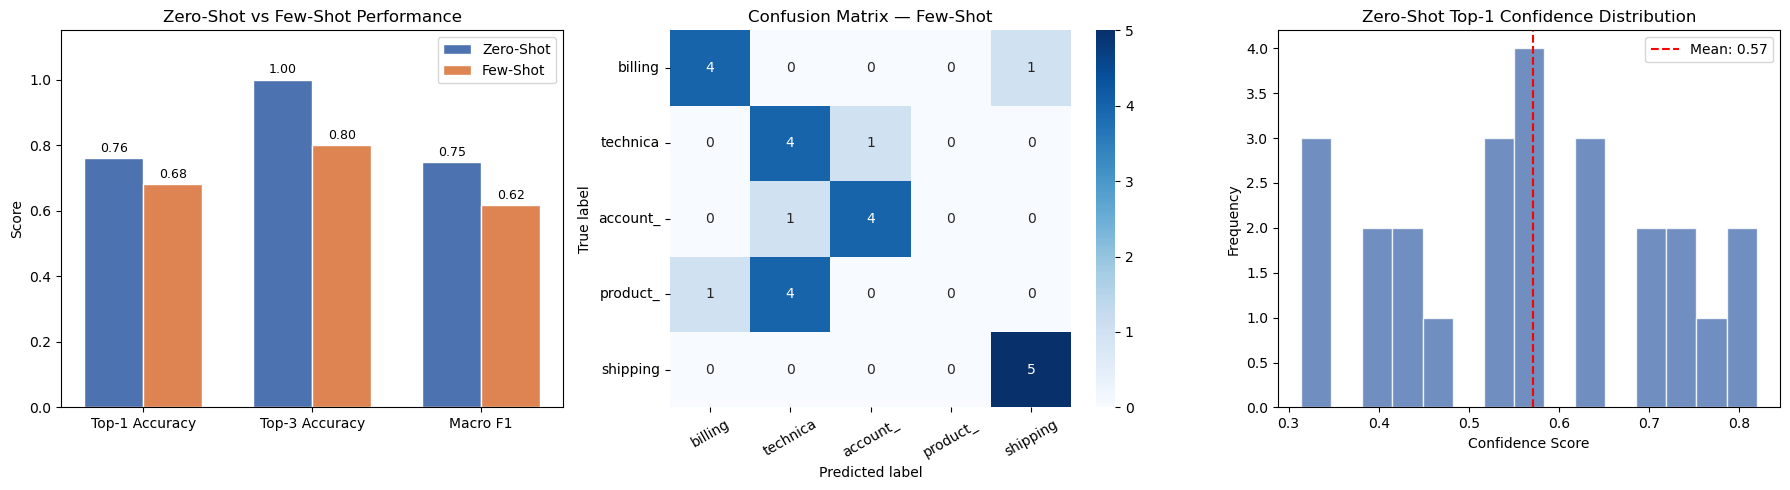

✅ Saved: evaluation_plots.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Bar chart: Zero-Shot vs Few-Shot metrics ──────────────────
metrics   = ["Top-1 Accuracy", "Top-3 Accuracy", "Macro F1"]
zs_scores = [zs_acc, zs_top3, zs_f1]
fs_scores = [fs_acc, fs_top3, fs_f1]
x         = np.arange(len(metrics))
width     = 0.35

bars1 = axes[0].bar(x - width/2, zs_scores, width, label="Zero-Shot",
                    color="#4C72B0", edgecolor="white")
bars2 = axes[0].bar(x + width/2, fs_scores, width, label="Few-Shot",
                    color="#DD8452", edgecolor="white")
axes[0].set_ylim(0, 1.15)
axes[0].set_title("Zero-Shot vs Few-Shot Performance", fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel("Score")
axes[0].legend()
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"{bar.get_height():.2f}", ha="center", fontsize=9)

# ── Confusion matrix — Few-Shot ───────────────────────────────
cm = confusion_matrix(fs_df["true_label"], fs_df["top_1"], labels=CATEGORIES)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[c[:8] for c in CATEGORIES],
            yticklabels=[c[:8] for c in CATEGORIES],
            ax=axes[1])
axes[1].set_title("Confusion Matrix — Few-Shot", fontsize=12)
axes[1].set_ylabel("True label")
axes[1].set_xlabel("Predicted label")
axes[1].tick_params(axis="x", rotation=30)
axes[1].tick_params(axis="y", rotation=0)

# ── Zero-Shot confidence distribution (scores only available here) ──
axes[2].hist(zs_df["confidence_1"], bins=15, alpha=0.8,
             color="#4C72B0", edgecolor="white")
axes[2].set_title("Zero-Shot Top-1 Confidence Distribution", fontsize=12)
axes[2].set_xlabel("Confidence Score")
axes[2].set_ylabel("Frequency")
axes[2].axvline(zs_df["confidence_1"].mean(), color="red",
                linestyle="--", label=f"Mean: {zs_df['confidence_1'].mean():.2f}")
axes[2].legend()

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: evaluation_plots.png")

In [25]:
print("FINAL TAGGED TICKETS \n")

print("── ZERO-SHOT RESULTS ──\n")
for _, row in zs_df.iterrows():
    correct = "✅" if row["top_1"] == row["true_label"] else "❌"
    print(f"Ticket #{row['ticket_id']:02d} {correct}")
    print(f"  Text    : {row['text'][:80]}...")
    print(f"  True    : {row['true_label']}")
    print(f"  Top Tags: [{row['top_1']} ({row['confidence_1']:.0%}), {row['top_2']}, {row['top_3']}]")
    print()

print("── FEW-SHOT RESULTS ──\n")
for _, row in fs_df.iterrows():
    correct = "✅" if row["top_1"] == row["true_label"] else "❌"
    print(f"Ticket #{row['ticket_id']:02d} {correct}")
    print(f"  Text    : {row['text'][:80]}...")
    print(f"  True    : {row['true_label']}")
    print(f"  Top Tags: [{row['top_1']}, {row['top_2']}, {row['top_3']}]")
    print()

FINAL TAGGED TICKETS 

── ZERO-SHOT RESULTS ──

Ticket #01 ✅
  Text    : I was charged twice for my subscription this month. Please refund the extra amou...
  True    : billing
  Top Tags: [billing (58%), account_management, product_feedback]

Ticket #02 ✅
  Text    : My invoice shows incorrect tax calculation. Can you correct and resend it?...
  True    : billing
  Top Tags: [billing (71%), account_management, technical_issue]

Ticket #03 ❌
  Text    : I cannot update my payment method. The page keeps throwing an error....
  True    : billing
  Top Tags: [technical_issue (34%), account_management, billing]

Ticket #04 ✅
  Text    : Why was my credit card declined even though it has sufficient funds?...
  True    : billing
  Top Tags: [billing (45%), account_management, technical_issue]

Ticket #05 ✅
  Text    : I need a receipt for my last three payments for expense reimbursement....
  True    : billing
  Top Tags: [billing (65%), account_management, product_feedback]

Ticket #06 ✅
  

In [26]:
# Save both results to CSV
zs_df.to_csv("zero_shot_results.csv", index=False)
fs_df.to_csv("few_shot_results.csv",  index=False)

print("✅ Saved: zero_shot_results.csv")
print("✅ Saved: few_shot_results.csv")
print(f"\nFiles saved:")

import os
for f in ["zero_shot_results.csv", "few_shot_results.csv",
          "eda_plots.png", "evaluation_plots.png"]:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f"  {f} ({size/1024:.1f} KB)")

✅ Saved: zero_shot_results.csv
✅ Saved: few_shot_results.csv

Files saved:
  zero_shot_results.csv (4.0 KB)
  few_shot_results.csv (3.3 KB)
  eda_plots.png (72.5 KB)
  evaluation_plots.png (111.2 KB)
